### Test - Legacy small box comparisons
</b> Author:   </b>  Sam MacKay

### Import relevant files:

In [1]:
import sys
import os

#top_level_path = resolve_path(str(os.path.dirname(os.path.realpath(__file__))) + "/../")
top_level_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
print("Setting top level path for imports:", top_level_path)

# Ensure top-level path is in sys.path
if top_level_path not in sys.path:
    # makes sure top level directory path is present in system so that relative imports work
    sys.path.insert(0, top_level_path)

import legacy.full_solver as fs

import importlib
importlib.reload(fs)

import numpy as np
import matplotlib.pyplot as plt

Setting top level path for imports: /home/administrator/Programs/synthPy/src


To use the ray tracer, first create a 'domain', load the domain with an electron distribution, calculate electron gradients, initialise a beam, and solve!
\
\
The output can either be plotted, or passed further through ray optics for synthetic diagnostics

In [2]:
extent_x = 5e-4
extent_y = 5e-4
extent_z = 10e-3

n_cells = 128

ne_x = np.linspace(-extent_x,extent_x, n_cells)
ne_y = np.linspace(-extent_y,extent_y, n_cells)
ne_z = np.linspace(-extent_z,extent_z, n_cells)

probing_extent = extent_z
probing_direction = 'z'

# define beam parameters
lwl = 1064e-9
beam_size = extent_x    # beam radius
beam_type = "circular"
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
divergence = 5e-5

slab = fs.ScalarDomain(ne_x, ne_y, ne_z, ne_extent)
slab.test_exponential_cos(n_e0 = 1e24, Ly = 1e-3, s = -2e-3)
slab.calc_dndr(lwl)

Solve gradients, initialise beam, and solve

In [3]:
## Initialise rays and solve
Np = 200000

s0 = fs.init_beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)

slab.solve(s0)
rf = slab.rf

Starting ray trace.
Ray trace completed in:	 13.996547222137451 s


In [4]:
from processing.plotting import graph_domain
from processing.plotting import general_ray_plots

l_x = 0
u_x = 0.3
l_y = -5
u_y = 5

from processing import diagnostics as diag

Completed updated ray trace in 13.996547222137451 seconds for 100000 rays in a 128^3 domain.

All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]

All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]


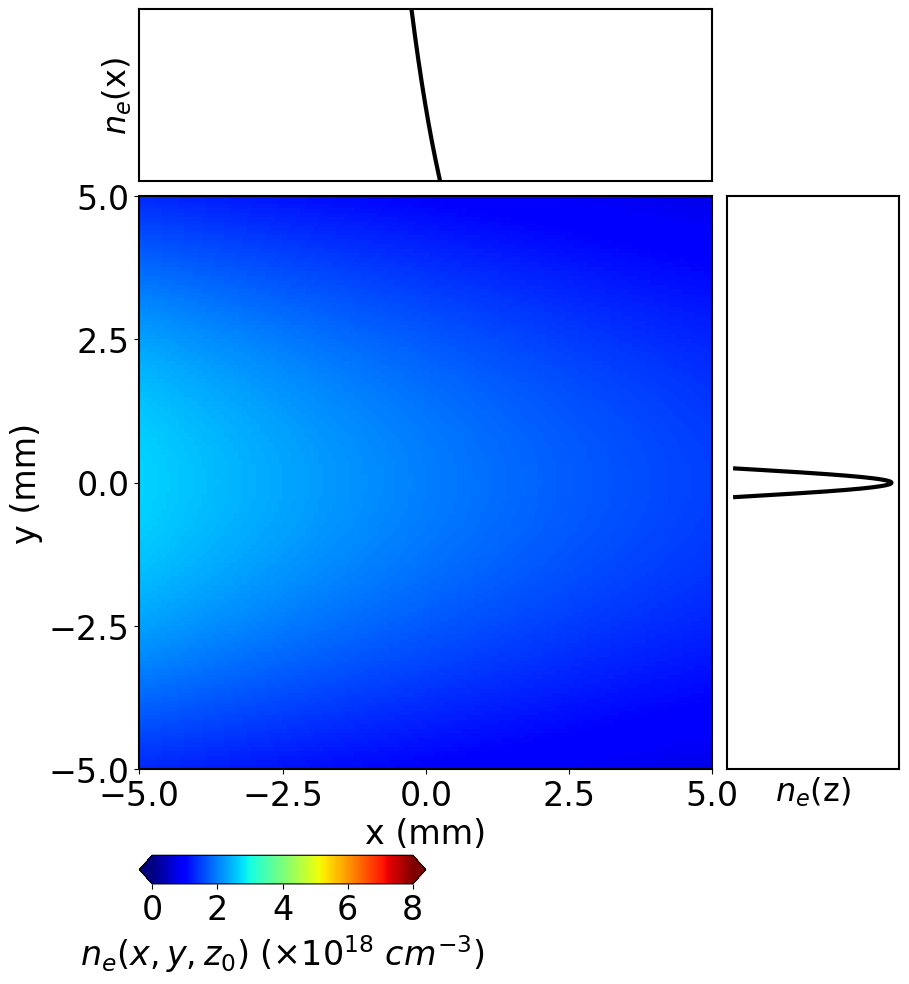

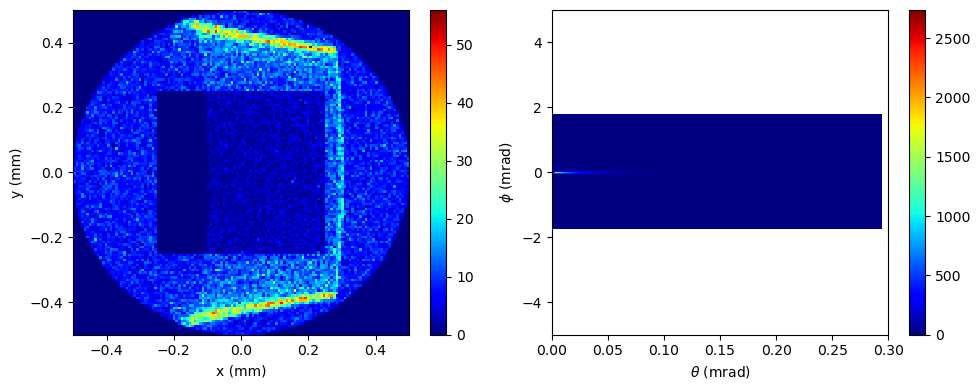

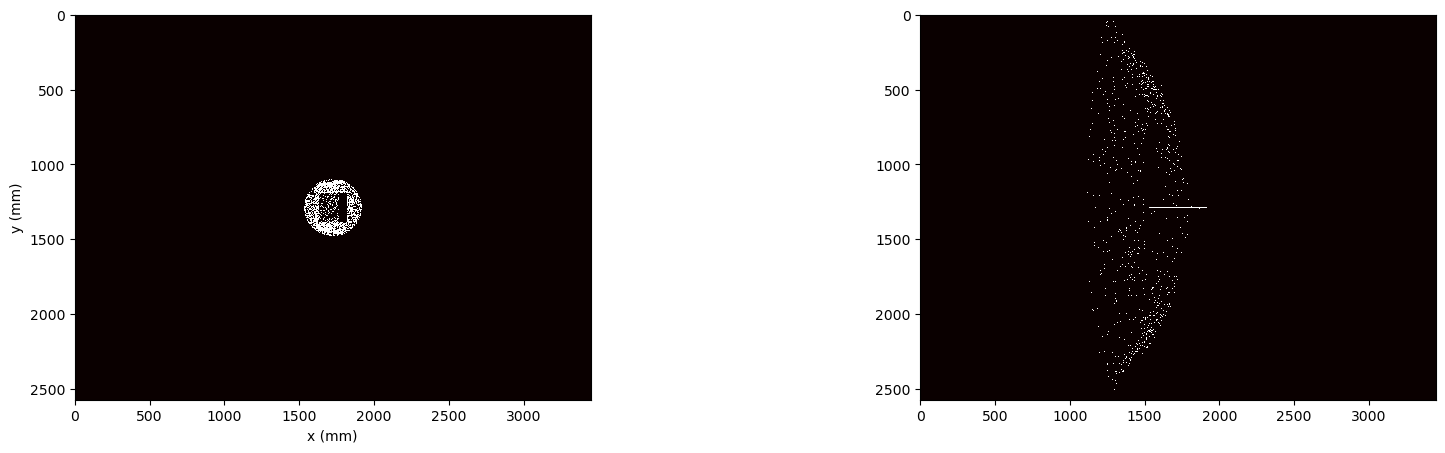

In [5]:
graph_domain(slab)

print("Completed updated ray trace in {} seconds for {} rays in a {}^3 domain.".format(slab.duration, Np, n_cells))

## Plot
general_ray_plots(rf, n_cells, lwl, l_x = l_x, u_x = u_x, l_y = l_y, u_y = u_y)


All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]

All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]


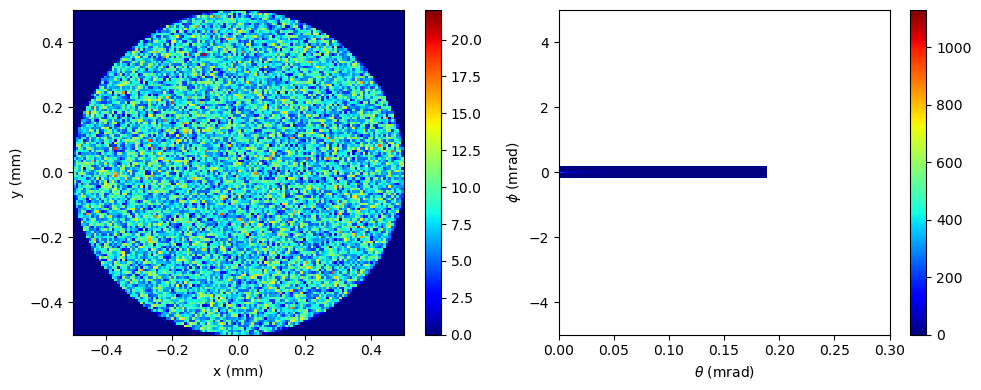

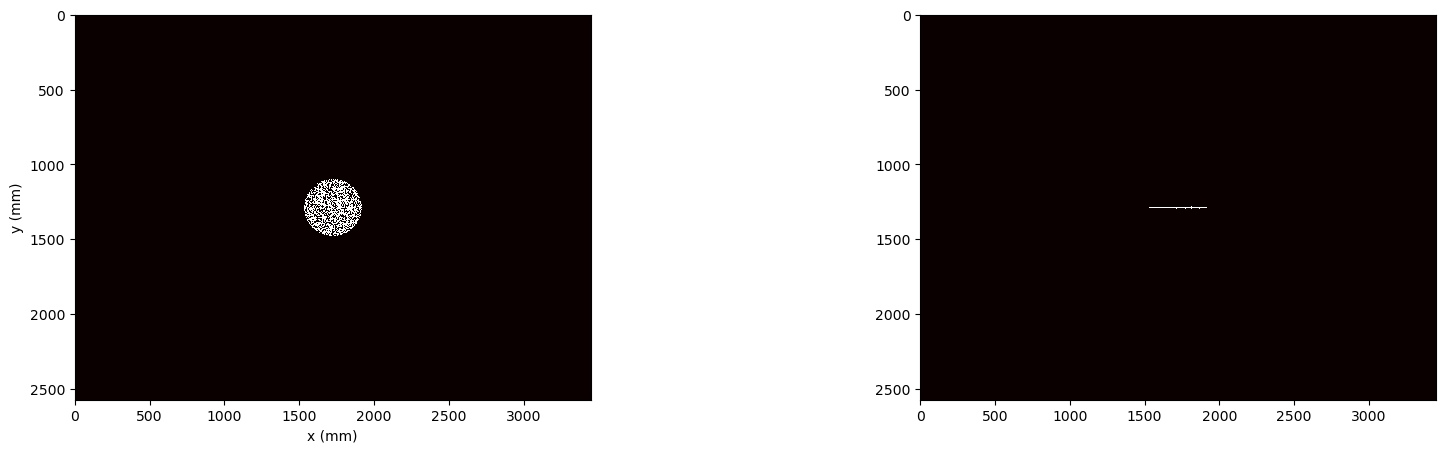

In [6]:
from shared.propagation import ray_to_Jonesvector

rf_legacy_raw, _ = ray_to_Jonesvector(s0, keep_current_plane = True)

general_ray_plots(rf_legacy_raw, n_cells, lwl, l_x = l_x, u_x = u_x, l_y = l_y, u_y = u_y)

Text(0, 0.5, 'e- density')

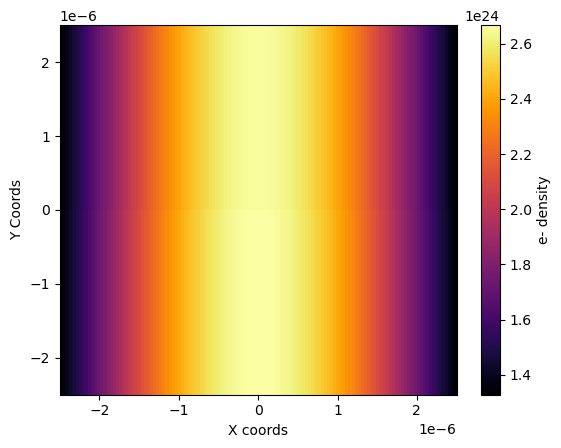

In [14]:
xy = slab.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [slab.x[0], slab.x[-1], slab.y[0], slab.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')


All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]


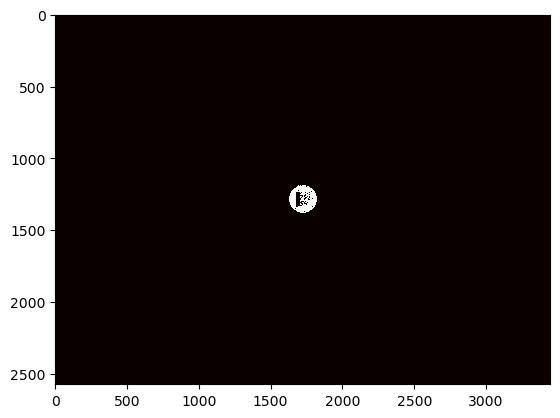

In [8]:
#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = diag.Refractometry(lwl, rf)
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.plot_rays(bin_scale = 1, clear_mem = False)

#information accessed by .H(istogram) , e.g plt.imshow(refractometer.H)

#plt.imshow(refractometer.H, cmap='hot', interpolation='nearest', clim = (0, 2))
plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


All rays incident on lens!


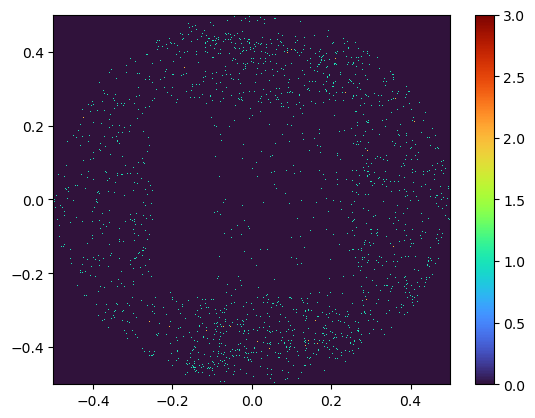

In [9]:
converter = diag.Refractometry(lwl, rf)
rf_mm = converter.r0
del converter

from shared.utils import heat_plot
heat_plot(rf_mm[0], rf_mm[2])

Pass through ray optics: For Shadowgaphy, Schlieren, or Refractometry:


All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]


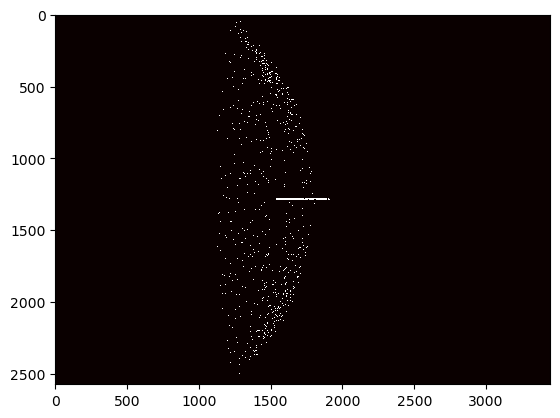

In [10]:
refractometer = diag.Refractometry(lwl, rf)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]


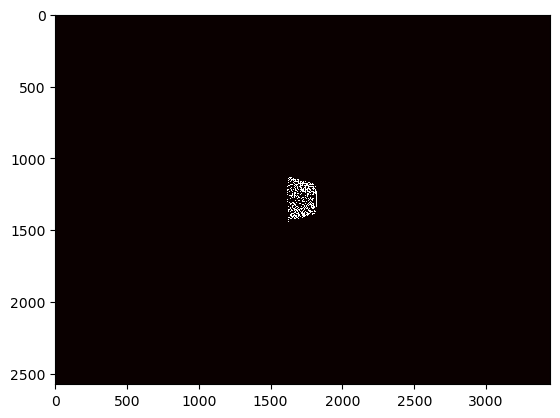

In [11]:
refractometer = diag.Refractometry(lwl, rf, L = 50)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [100000. 100000.]


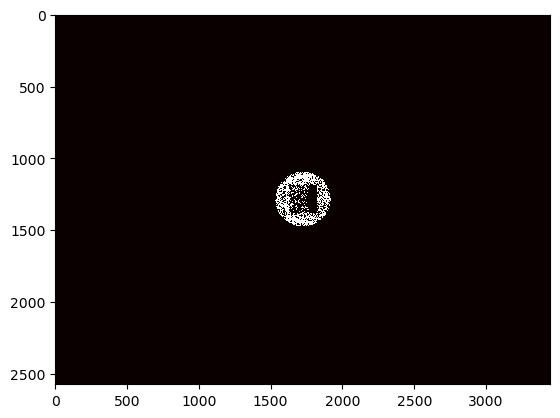

In [12]:
shadowgrapher = diag.Shadowgraphy(lwl, rf)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(shadowgrapher.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


All rays incident on lens!

rf size expected: [100000. 100000.]
rf after clearing nan's: [31626. 31626.]


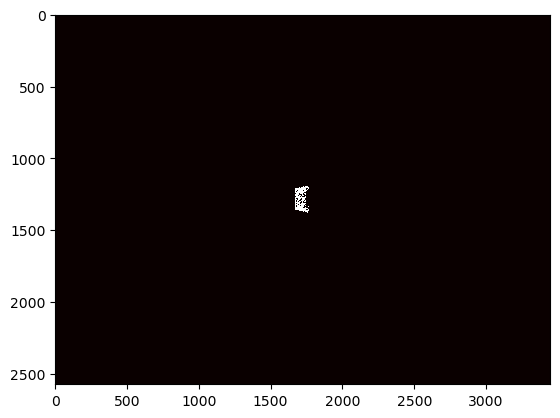

In [13]:
schlierener = diag.Schlieren(lwl, rf)
schlierener.DF_solve()
schlierener.histogram(bin_scale = 1, clear_mem = True)

plt.imshow(schlierener.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))